In [3]:
%load_ext rpy2.ipython

In [4]:
%%R
install.packages("tidyverse")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/tidyverse_2.0.0.tar.gz'
Content type 'application/x-gzip' length 704618 bytes (688 KB)
downloaded 688 KB


The downloaded source packages are in
	‘/tmp/RtmpcguKOA/downloaded_packages’


In [5]:
%%R

library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [6]:
%%R

deliveries <- read_csv("deliveries.csv")
complaints <- read_csv("complaints.csv")
incidents <- read_csv("incidents.csv")

Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): delivery_id, order_id, driver_id, vehicle_id, hub_id, delivery_status
dbl  (5): route_distance_km, manual_route_override_count, proof_of_completio...
dttm (2): dispatch_time, delivery_completed_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 320 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): complaint_id, customer_id, order_id, complaint_type, channel, seve...
dbl  (2): resolution_days, compensation_amount
dttm (1): created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 280 Columns: 7
── Column specification ──────────────────────────────────────────────────────

In [7]:
%%R

colnames(deliveries)

 [1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"          


In [8]:
%%R

delivery_status_summary <- deliveries %>%
group_by(delivery_status) %>%
summarise(total_deliveries = n())

delivery_status_summary

# A tibble: 3 × 2
  delivery_status total_deliveries
  <chr>                      <int>
1 Delayed                      202
2 Failed                       132
3 OnTime                       616


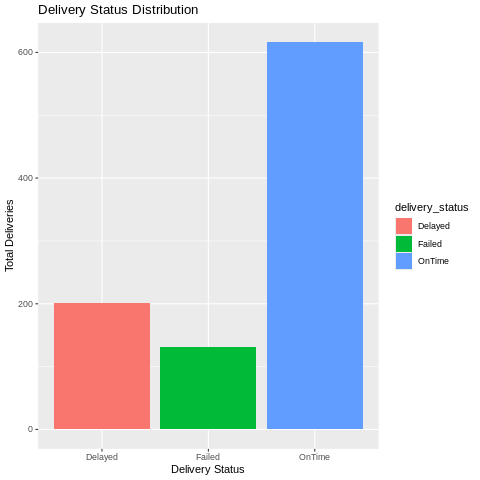

In [9]:
%%R

ggplot(delivery_status_summary,
aes(x = delivery_status,
y = total_deliveries,
fill = delivery_status)) +
geom_bar(stat = "identity") +
labs(title = "Delivery Status Distribution",
x = "Delivery Status",
y = "Total Deliveries")

In [10]:
%%R

override_summary <- deliveries %>%
group_by(driver_id) %>%
summarise(total_overrides =
sum(manual_route_override_count,
na.rm = TRUE))

override_summary

# A tibble: 170 × 2
   driver_id total_overrides
   <chr>               <dbl>
 1 D001                    4
 2 D002                    7
 3 D003                    7
 4 D004                    7
 5 D005                    6
 6 D006                    3
 7 D007                    0
 8 D008                   12
 9 D009                    4
10 D010                    6
# ℹ 160 more rows
# ℹ Use `print(n = ...)` to see more rows


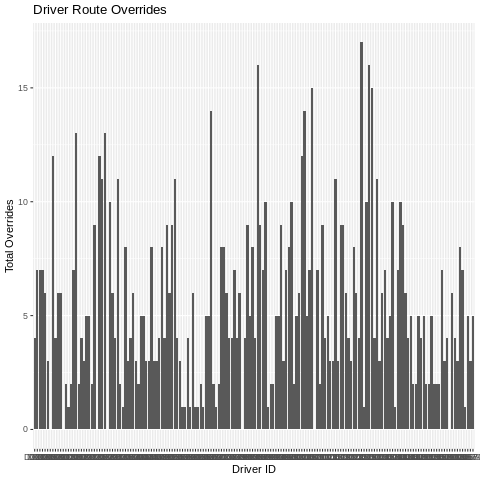

In [11]:
%%R

ggplot(override_summary,
aes(x = driver_id,
y = total_overrides)) +
geom_bar(stat = "identity") +
labs(title = "Driver Route Overrides",
x = "Driver ID",
y = "Total Overrides")

In [12]:
%%R

rating_summary <- deliveries %>%
group_by(delivery_status) %>%
summarise(avg_rating =
mean(customer_rating_post_delivery,
na.rm = TRUE))

rating_summary

# A tibble: 3 × 2
  delivery_status avg_rating
  <chr>                <dbl>
1 Delayed               3.11
2 Failed                3.05
3 OnTime                4.28


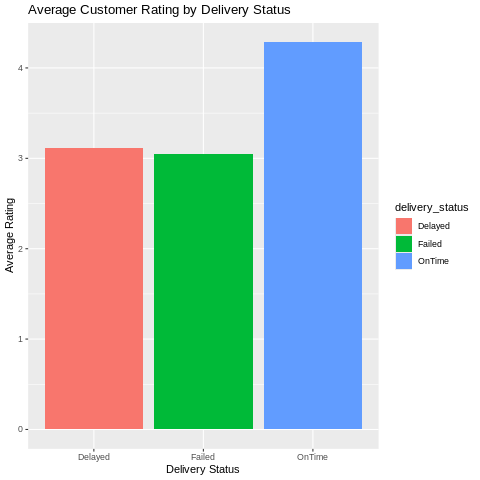

In [13]:
%%R

ggplot(rating_summary,
aes(x = delivery_status,
y = avg_rating,
fill = delivery_status)) +
geom_bar(stat = "identity") +
labs(title = "Average Customer Rating by Delivery Status",
x = "Delivery Status",
y = "Average Rating")

In [14]:
%%R

distance_summary <- deliveries %>%
group_by(hub_id) %>%
summarise(avg_distance =
mean(route_distance_km,
na.rm = TRUE))

distance_summary

# A tibble: 8 × 2
  hub_id avg_distance
  <chr>         <dbl>
1 H01            13.6
2 H02            14.2
3 H03            14.5
4 H04            13.4
5 H05            14.3
6 H06            14.4
7 H07            14.3
8 H08            12.8


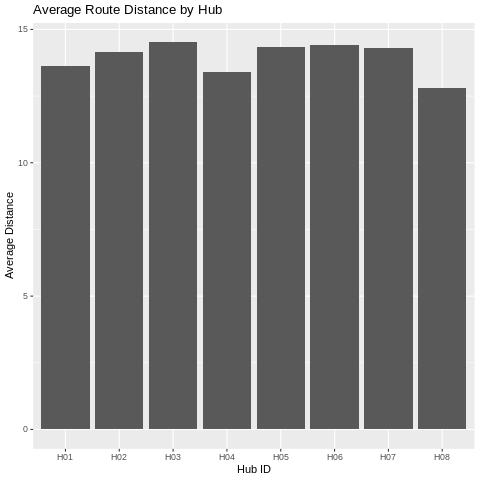

In [15]:
%%R

ggplot(distance_summary,
aes(x = hub_id,
y = avg_distance)) +
geom_bar(stat = "identity") +
labs(title = "Average Route Distance by Hub",
x = "Hub ID",
y = "Average Distance")

In [16]:
%%R

proof_summary <- deliveries %>%
group_by(proof_of_completion_missing) %>%
summarise(total_cases = n())

proof_summary

# A tibble: 2 × 2
  proof_of_completion_missing total_cases
                        <dbl>       <int>
1                           0         881
2                           1          69


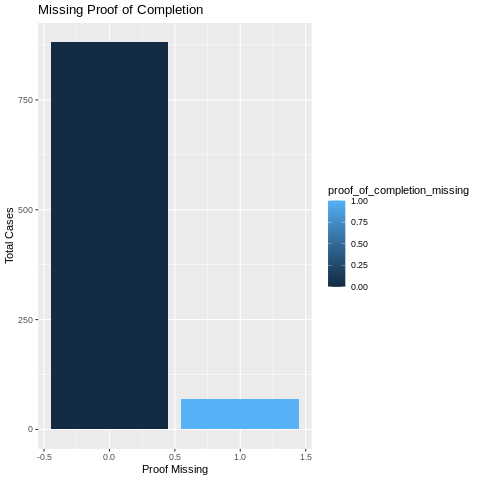

In [17]:
%%R

ggplot(proof_summary,
aes(x = proof_of_completion_missing,
y = total_cases,
fill = proof_of_completion_missing)) +
geom_bar(stat = "identity") +
labs(title = "Missing Proof of Completion",
x = "Proof Missing",
y = "Total Cases")